In [1]:
%matplotlib inline

import h5py
import numpy as np
from matplotlib import pyplot as plt
import torch

In [2]:
file_path = 'singlecoil_train/file1000027.h5'
# file_path = 'singlecoil_test/file1000022.h5'

hf = h5py.File(file_path, 'r')

In [3]:
print('Keys in the HDF5 file:', list(hf.keys()))
print('Attributes in the HDF5 file:', list(hf.attrs))

Keys in the HDF5 file: ['ismrmrd_header', 'kspace', 'reconstruction_esc', 'reconstruction_rss']
Attributes in the HDF5 file: ['acquisition', 'max', 'norm', 'patient_id']


In [4]:
hf.attrs['acquisition']

'CORPDFS_FBK'

(320, 320)


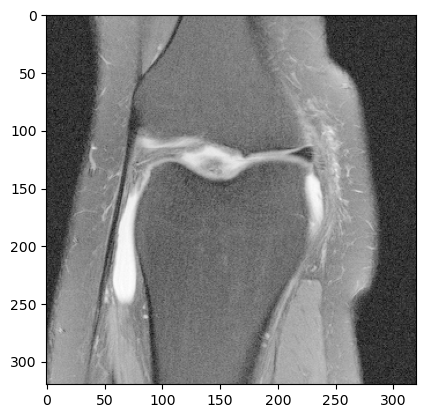

In [5]:
rss = hf['reconstruction_rss'][()]

slice_id = 15
singlecoil_kspace_slice = rss[slice_id]
print(singlecoil_kspace_slice.shape)

plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9), cmap="gray") 
plt.show()

In [6]:
kspace = hf['kspace'][()]
# mask = hf['mask'][()]
# kspace = kspace * mask
print(kspace.dtype)
print(kspace.shape)
# print(mask.dtype)
# print(mask.shape)

complex64
(34, 640, 368)


(640, 368)


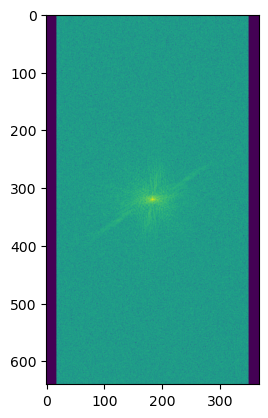

In [7]:
slice_id = 20
singlecoil_kspace_slice = kspace[slice_id]
print(singlecoil_kspace_slice.shape)

plt.imshow(np.log(np.abs(singlecoil_kspace_slice) + 1e-9))
plt.show()

In [94]:
import fastmri.data.transforms as T
singlecoil_kspace_tensor = T.to_tensor(kspace)

singlecoil_kspace_tensor.shape

torch.Size([34, 640, 368, 2])

In [95]:
import fastmri
singlecoil_sampled_image = fastmri.ifft2c(singlecoil_kspace_tensor)
singlecoil_sampled_image.shape

torch.Size([34, 640, 368, 2])

In [96]:
singlecoil_sampled_image_abs = fastmri.complex_abs(singlecoil_sampled_image)
singlecoil_sampled_image_abs.shape

torch.Size([34, 640, 368])

In [97]:
def show_slices(data, slice_nums, cmap=None):
    fig = plt.figure()
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        print(data.shape)
        print(data.dtype)
        plt.imshow(data, cmap=cmap)


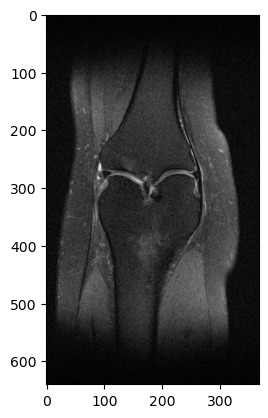

In [98]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray") # ?
plt.show()

In [99]:
#Normalize the image
singlecoil_sampled_image_abs = (singlecoil_sampled_image_abs - singlecoil_sampled_image_abs.min()) / (singlecoil_sampled_image_abs.max() - singlecoil_sampled_image_abs.min())

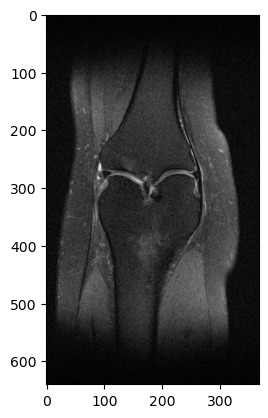

In [100]:
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray") # ?
plt.show()

In [104]:
#Create bounding box for image ((100-150, 200-400)) (X,Y)

#Generate random coordinates inside bounding box to center screw
x_min = np.random.randint(100, 150)
y_min = np.random.randint(200, 400)

#Replace area around location with cross pattern
cross_size = 9
thickness = 3
for t in range(-thickness, thickness + 1):  # Loop to create thickness of the cross
    for i in range(-cross_size, cross_size + 1):
        if 0 <= x_min + i < singlecoil_sampled_image_abs.shape[2]:  # Check bounds for x
            singlecoil_sampled_image_abs[slice_id, y_min + i, x_min + t] = np.random.rand()*0.05  # Set vertical line of cross
        if 0 <= y_min + i < singlecoil_sampled_image_abs.shape[1]:  # Check bounds for y
            singlecoil_sampled_image_abs[slice_id, y_min + t, x_min + i] = np.random.rand()*0.05  # Set horizontal line of cross

In [105]:
print(x_min)
print(y_min)

134
231


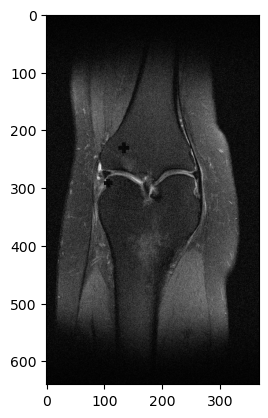

In [106]:
#display modified image
plt.imshow(singlecoil_sampled_image_abs[slice_id].numpy(), cmap="gray", aspect='equal')
plt.show()